# Proyek Analisis Data: [Bike Sharing]
- **Nama:** [Rezha Dwi Cahya Ardinata]
- **Email:** [cdcc006d6y1939@student.devacademy.id]
- **ID Dicoding:** [rezhadwii]

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pola perubahan jumlah penyewaan sepeda setiap bulan selama tahun 2011–2012?
- **Pertanyaan 2:** Bagaimana perbedaan rata-rata penyewaan sepeda pada tiap musim dan kondisi cuaca selama tahun 2011–2012?
- **Pertanyaan 3:** Bagaimana pola rata-rata penyewaan sepeda berdasarkan jam dalam sehari selama tahun 2011–2012?

### Import Semua Packages/Library yang Digunakan

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [22]:
hour_bike = pd.read_csv("/content/hour.csv")
hour_bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight**

Lima baris pertama menunjukkan bahwa dataset ini berisi catatan penyewaan sepeda per jam. Informasi waktu tersedia pada kolom seperti `dteday`, `yr`, `mnth`, `hr`, dan `weekday`. Kondisi eksternal seperti musim dan cuaca terdapat pada kolom `season`, `weathersit`, `temp`, `hum`, dan `windspeed`. Kolom `casual`, `registered`, dan `cnt` menunjukkan jumlah penyewaan sepeda.

### Assessing Data

**Steps to Take:**
- Memeriksa struktur data dan tipe data pada setiap kolom.
- Memeriksa missing value pada dataset.
- Memeriksa duplicate data.
- Melihat ringkasan statistik.

In [23]:
hour_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [24]:
hour_bike.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [25]:
hour_bike.duplicated().sum()

np.int64(0)

In [26]:
hour_bike.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**

- Dataset hour_bike terdiri dari 17.379 catatan penyewaan sepeda per jam dan 17 kolom.
- Tidak ditemukan missing value pada seluruh kolom, sehingga tidak diperlukan proses imputasi atau penghapusan nilai kosong.
- Tidak ditemukan data duplikat, sehingga dataset dapat digunakan tanpa proses penghapusan duplikasi.
- Kolom dteday masih bertipe object, perlu diubah menjadi tipe datetime agar dapat digunakan untuk analisis berbasis waktu.
- Nilai pada kolom cnt berada pada rentang 1 hingga 977 penyewaan per jam, menunjukkan adanya variasi jumlah penyewaan yang cukup besar antarwaktu.

### Cleaning Data

In [37]:
# Mengubah kolom dteday menjadi tipe datetime
hour_bike["dteday"] = pd.to_datetime(hour_bike["dteday"])

In [38]:
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

hour_bike["season"] = hour_bike["season"].map(season_map)

In [39]:
weather_map = {
    1: "Clear",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

hour_bike["weathersit"] = hour_bike["weathersit"].map(weather_map)

In [41]:
year_map = {
    0: 2011,
    1: 2012
}

hour_bike["yr"] = hour_bike["yr"].map(year_map)

In [42]:
month_map = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

hour_bike["mnth"] = hour_bike["mnth"].map(month_map)

In [43]:
workingday_map = {
    0: "Non-Working Day",
    1: "Working Day"
}

hour_bike["workingday"] = hour_bike["workingday"].map(workingday_map)

In [44]:
weekday_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

hour_bike["weekday"] = hour_bike["weekday"].map(weekday_map)

In [47]:
hour_bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,January,0,0,Saturday,Non-Working Day,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,0,Saturday,Non-Working Day,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,0,Saturday,Non-Working Day,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,0,Saturday,Non-Working Day,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,0,Saturday,Non-Working Day,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

- Pada tahap cleaning, kolom dteday sudah diubah ke tipe datetime. Hal ini dilakukan karena kolom tersebut berisi tanggal, sehingga lebih mudah digunakan untuk analisis yang berhubungan dengan waktu.

- Beberapa kolom yang awalnya masih berupa kode angka juga sudah diubah menjadi keterangan teks. Misalnya, kolom season diubah menjadi nama musim, mnth menjadi nama bulan, weekday menjadi nama hari, dan weathersit menjadi keterangan kondisi cuaca.

- Pada tahap sebelumnya tidak ditemukan missing value maupun data duplikat, sehingga tidak ada proses penghapusan atau pengisian nilai kosong yang dilakukan.

- Setelah proses cleaning, dataset menjadi lebih siap digunakan untuk tahap EDA, terutama untuk menganalisis pola penyewaan sepeda berdasarkan waktu, musim, hari, hari kerja, dan kondisi cuaca.

## Exploratory Data Analysis (EDA)

In [48]:
hour_bike.describe()

,instant,dteday,yr,hr,holiday,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2011.502561,11.546752,0.028770,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,2011.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2011.000000,6.000000,0.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,2012.000000,12.000000,0.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,2012.000000,18.000000,0.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,2012.000000,23.000000,1.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,0.500008,6.914405,0.167165,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [56]:
# Mengelompokkan data berdasarkan tahun dan bulan untuk melihat total penyewaan sepeda setiap bulan
monthly_rentals = hour_bike.groupby(["yr", "mnth"], as_index=False).agg({
    "cnt": "sum"
})

monthly_rentals

,yr,mnth,cnt
0,2011,April,94870
1,2011,August,136691
2,2011,December,87323
3,2011,February,48215
4,2011,January,38189
5,2011,July,141341
6,2011,June,143512
7,2011,March,64045
8,2011,May,135821
9,2011,November,102167


In [59]:
# Menampilkan bulan dengan total penyewaan sepeda tertinggi
monthly_rentals.sort_values(by="cnt", ascending=False).head()

,yr,mnth,cnt
23,2012,September,218573
13,2012,August,214503
17,2012,July,203607
18,2012,June,202830
22,2012,October,198841


In [60]:
# Menampilkan bulan dengan total penyewaan sepeda terendah
monthly_rentals.sort_values(by="cnt", ascending=True).head()

,yr,mnth,cnt
4,2011,January,38189
3,2011,February,48215
7,2011,March,64045
2,2011,December,87323
0,2011,April,94870


In [61]:
# Menghitung rata-rata penyewaan sepeda berdasarkan musim
season_rentals = hour_bike.groupby("season", as_index=False).agg({
    "cnt": "mean"
})

season_rentals.sort_values(by="cnt", ascending=False)

,season,cnt
0,Fall,236.016237
2,Summer,208.344069
3,Winter,198.868856
1,Spring,111.114569


In [62]:
# Menghitung rata-rata penyewaan sepeda berdasarkan kondisi cuaca
weather_rentals = hour_bike.groupby("weathersit", as_index=False).agg({
    "cnt": "mean"
})

weather_rentals.sort_values(by="cnt", ascending=False)

,weathersit,cnt
0,Clear,204.869272
3,Mist/Cloudy,175.165493
2,Light Rain/Snow,111.579281
1,Heavy Rain/Snow,74.333333


In [65]:
# Menghitung rata-rata penyewaan sepeda berdasarkan jam dalam sehari
hourly_rentals = hour_bike.groupby("hr", as_index=False).agg({
    "cnt": "mean"
})

hourly_rentals.sort_values(by="cnt", ascending=False)

,hr,cnt
17,17,461.452055
18,18,425.510989
8,8,359.011004
16,16,311.983562
19,19,311.523352
13,13,253.661180
12,12,253.315934
15,15,251.233196
14,14,240.949246
20,20,226.030220


**Insight:**
- Setelah data dikelompokkan berdasarkan tahun dan bulan, terlihat bahwa penyewaan sepeda pada tahun 2012 lebih tinggi dibandingkan tahun 2011. Total penyewaan paling tinggi terjadi pada September 2012 dengan 218.573 penyewaan, sedangkan yang paling rendah terjadi pada Januari 2011 dengan 38.189 penyewaan.

- Berdasarkan musim, musim fall atau musim gugur memiliki rata-rata penyewaan paling tinggi, yaitu sekitar 236 penyewaan per jam. Pada musim spring atau musim semi memiliki rata-rata penyewaan paling rendah, yaitu sekitar 111 penyewaan per jam.

- Kondisi cuaca juga menunjukkan perbedaan pada rata-rata penyewaan sepeda. Saat cuaca clear atau cerah, rata-rata penyewaan mencapai sekitar 205 penyewaan per jam. Angka ini menurun pada kondisi mist/cloudy atau berkabut/berawan dan light rain/snow atau hujan/salju ringan, lalu menjadi paling rendah pada kondisi Heavy Rain/Snow atau hujan/salju lebat.

- Pada analisis berdasarkan jam, rata-rata penyewaan tertinggi terjadi pada jam 17.00, sedangkan nilai tertinggi berikutnya terjadi pada jam 18.00. Hal ini menunjukkan bahwa sore hari merupakan salah satu periode penyewaan yang ramai.


## Visualization & Explanatory Analysis

### Pertanyaan 1:Bagaimana pola perubahan jumlah penyewaan sepeda setiap bulan selama tahun 2011–2012?

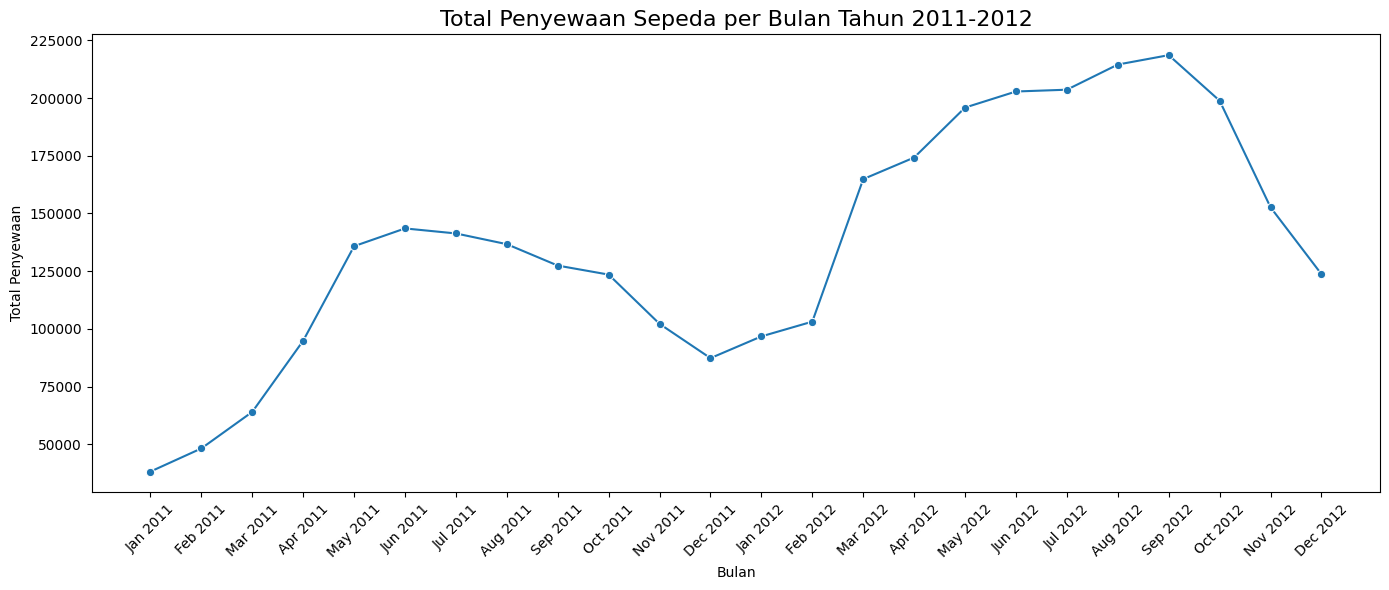

In [79]:
monthly_rentals_viz = hour_bike.resample(rule="ME", on="dteday").agg({
    "cnt": "sum"
}).reset_index()

monthly_rentals_viz["month_year"] = monthly_rentals_viz["dteday"].dt.strftime("%b %Y")

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_rentals_viz,
    x="month_year",
    y="cnt",
    marker="o"
)

plt.title("Total Penyewaan Sepeda per Bulan Tahun 2011-2012", fontsize=16)
plt.xlabel("Bulan")
plt.ylabel("Total Penyewaan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana perbedaan rata-rata penyewaan sepeda pada tiap musim dan kondisi cuaca selama tahun 2011–2012?

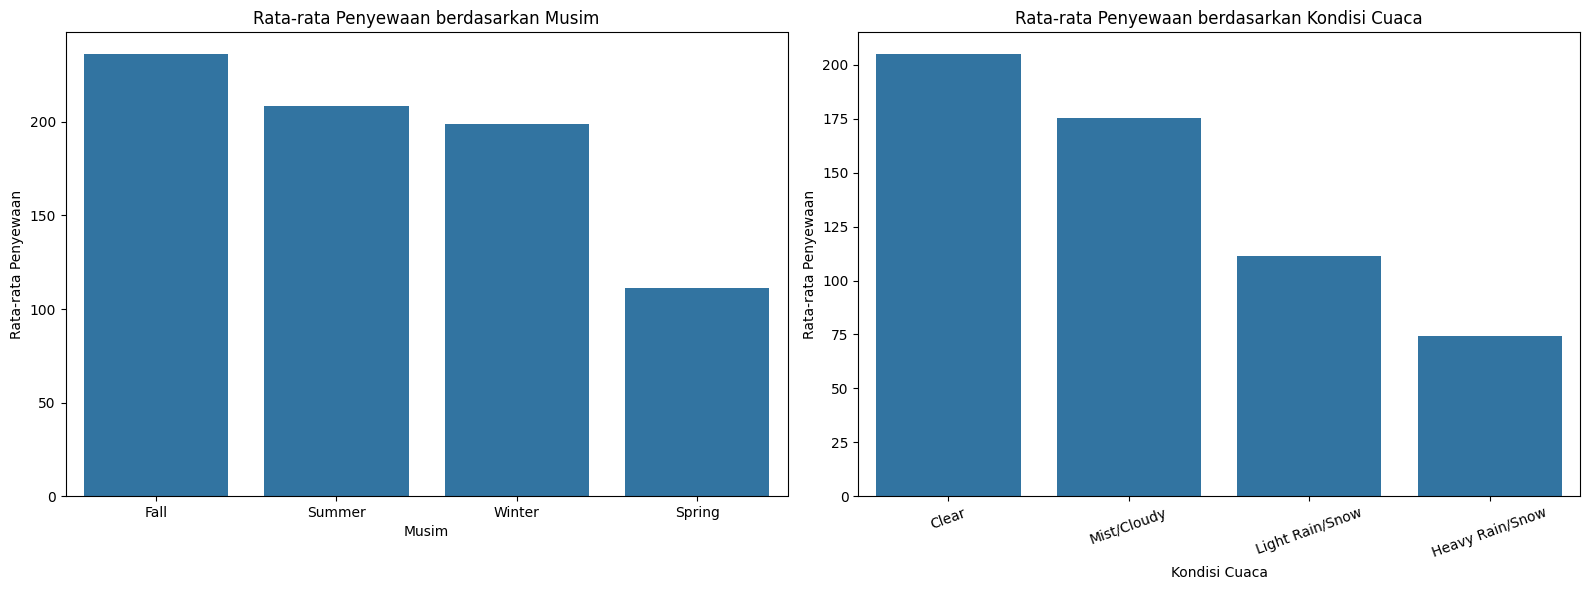

In [78]:
season_rentals = hour_bike.groupby("season", as_index=False).agg({
    "cnt": "mean"
})

weather_rentals = hour_bike.groupby("weathersit", as_index=False).agg({
    "cnt": "mean"
})

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.barplot(
    data=season_rentals.sort_values(by="cnt", ascending=False),
    x="season",
    y="cnt",
    ax=ax[0]
)
ax[0].set_title("Rata-rata Penyewaan berdasarkan Musim")
ax[0].set_xlabel("Musim")
ax[0].set_ylabel("Rata-rata Penyewaan")

sns.barplot(
    data=weather_rentals.sort_values(by="cnt", ascending=False),
    x="weathersit",
    y="cnt",
    ax=ax[1]
)
ax[1].set_title("Rata-rata Penyewaan berdasarkan Kondisi Cuaca")
ax[1].set_xlabel("Kondisi Cuaca")
ax[1].set_ylabel("Rata-rata Penyewaan")
ax[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Pertanyaan 3: Bagaimana pola rata-rata penyewaan sepeda berdasarkan jam dalam sehari selama tahun 2011–2012?

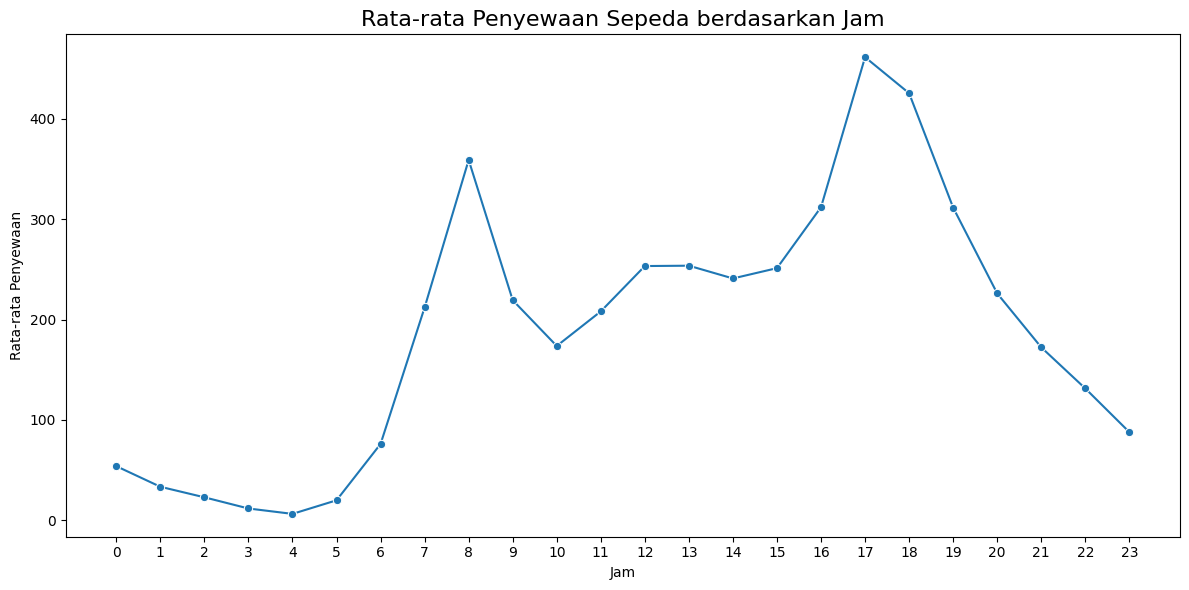

In [77]:
hourly_rentals = hour_bike.groupby("hr", as_index=False).agg({
    "cnt": "mean"
})

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hourly_rentals,
    x="hr",
    y="cnt",
    marker="o"
)

plt.title("Rata-rata Penyewaan Sepeda berdasarkan Jam", fontsize=16)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Insight:**

- Pada pertanyaan pertama, grafik tren bulanan menunjukkan bahwa jumlah penyewaan sepeda cenderung meningkat dari awal 2011 hingga pertengahan tahun. Memasuki tahun 2012, jumlah penyewaan terlihat lebih tinggi dibandingkan tahun sebelumnya. Titik tertinggi terjadi sekitar September 2012, kemudian jumlah penyewaan mulai menurun menjelang akhir tahun.

- Pada pertanyaan kedua, terlihat dari sisi musim dan cuaca bahwa rata-rata penyewaan sepeda tidak sama pada setiap kondisi. Musim Fall atau musim gugur memiliki rata-rata penyewaan paling tinggi, sedangkan Spring atau musim semi memiliki rata-rata paling rendah. Penyewaan paling tinggi terjadi saat cuaca Clear, yaitu cuaca cerah atau relatif baik. Sebaliknya, rata-rata penyewaan menurun ketika cuaca mulai kurang mendukung, seperti Mist/Cloudy atau berkabut/berawan, Light Rain/Snow atau hujan/salju ringan, hingga Heavy Rain/Snow atau hujan/salju lebat.

- Pada pertanyaan ketiga, grafik berdasarkan jam menunjukkan bahwa penyewaan sepeda tidak tersebar merata sepanjang hari. Rata-rata penyewaan mulai naik pada pagi hari, terutama sekitar jam 08.00. Setelah itu, jumlah penyewaan kembali meningkat pada sore hari dan mencapai nilai tertinggi sekitar jam 17.00. Pola ini menunjukkan bahwa sepeda banyak digunakan pada waktu aktivitas harian, terutama saat berangkat dan pulang kerja atau sekolah.

## Analisis Lanjutan (Opsional)

Pada analisis lanjutan ini dilakukan pengelompokan jam berdasarkan rata-rata jumlah penyewaan sepeda. Pengelompokan dilakukan secara manual menjadi tiga kategori, yaitu Low Demand, Medium Demand, dan High Demand.


In [70]:
hourly_demand = hour_bike.groupby("hr", as_index=False).agg({
    "cnt": "mean"
})

hourly_demand

,hr,cnt
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941
5,5,19.889819
6,6,76.044138
7,7,212.064649
8,8,359.011004
9,9,219.309491


In [71]:
def demand_level(avg_rentals):
    if avg_rentals < 150:
        return "Low Demand"
    elif avg_rentals < 300:
        return "Medium Demand"
    else:
        return "High Demand"

hourly_demand["demand_level"] = hourly_demand["cnt"].apply(demand_level)

hourly_demand

,hr,cnt,demand_level
0,0,53.898072,Low Demand
1,1,33.375691,Low Demand
2,2,22.869930,Low Demand
3,3,11.727403,Low Demand
4,4,6.352941,Low Demand
5,5,19.889819,Low Demand
6,6,76.044138,Low Demand
7,7,212.064649,Medium Demand
8,8,359.011004,High Demand
9,9,219.309491,Medium Demand


In [72]:
hourly_demand.groupby("demand_level").agg({
    "hr": list,
    "cnt": "mean"
})

,hr,cnt
demand_level,,
High Demand,"[8, 16, 17, 18, 19]",373.896192
Low Demand,"[0, 1, 2, 3, 4, 5, 6, 22, 23]",49.258245
Medium Demand,"[7, 9, 10, 11, 12, 13, 14, 15, 20, 21]",221.069003


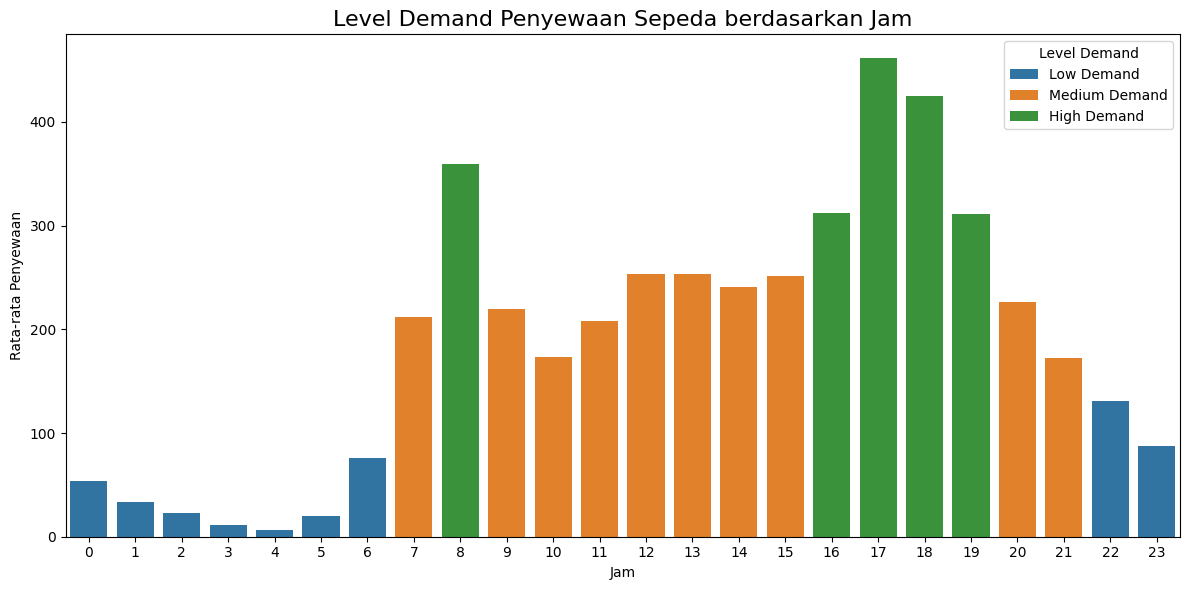

In [76]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=hourly_demand,
    x="hr",
    y="cnt",
    hue="demand_level"
)

plt.title("Level Demand Penyewaan Sepeda berdasarkan Jam", fontsize=16)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0, 24))
plt.legend(title="Level Demand")
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**  
  Pertanyaan: Bagaimana pola perubahan jumlah penyewaan sepeda setiap bulan selama tahun 2011–2012?  
  
  Berdasarkan hasil analisis, jumlah penyewaan sepeda mengalami perubahan dari bulan ke bulan. Pada tahun 2011, penyewaan masih relatif rendah di awal tahun, kemudian meningkat pada pertengahan tahun. Pada tahun 2012, jumlah penyewaan terlihat lebih tinggi dibandingkan tahun 2011. Total penyewaan tertinggi terjadi pada September 2012 dengan 218.573 penyewaan, sedangkan total penyewaan terendah terjadi pada Januari 2011 dengan 38.189 penyewaan. Hal ini menunjukkan bahwa penggunaan layanan bike sharing mengalami peningkatan dari tahun 2011 ke tahun 2012.

- **Conclusion pertanyaan 2:**  
  Pertanyaan: Bagaimana perbedaan rata-rata penyewaan sepeda pada tiap musim dan kondisi cuaca selama tahun 2011–2012?  
  
  Rata-rata penyewaan sepeda berbeda pada setiap musim dan kondisi cuaca. Dari sisi musim, Fall atau musim gugur memiliki rata-rata penyewaan tertinggi, yaitu sekitar 236 penyewaan per jam. Sebaliknya, Spring atau musim semi memiliki rata-rata penyewaan paling rendah, yaitu sekitar 111 penyewaan per jam. Dari sisi kondisi cuaca, rata-rata penyewaan tertinggi terjadi saat cuaca Clear, yaitu kondisi cuaca cerah atau relatif baik, dengan rata-rata sekitar 205 penyewaan per jam. Rata-rata penyewaan menurun pada kondisi Mist/Cloudy, yaitu berkabut atau berawan, serta Light Rain/Snow, yaitu hujan atau salju ringan. Rata-rata penyewaan paling rendah terjadi pada kondisi Heavy Rain/Snow, yaitu hujan atau salju lebat. Hasil ini menunjukkan bahwa musim dan cuaca memiliki peran dalam perubahan tingkat penyewaan sepeda.

- **Conclusion pertanyaan 3:**  
  Pertanyaan: Bagaimana pola rata-rata penyewaan sepeda berdasarkan jam dalam sehari selama tahun 2011–2012?  

  Pola penyewaan sepeda berdasarkan jam menunjukkan bahwa rata-rata penyewaan tidak merata sepanjang hari. Penyewaan mulai meningkat pada pagi hari, terutama sekitar jam 08.00. Setelah itu, penyewaan kembali meningkat pada sore hari dan mencapai rata-rata tertinggi pada jam 17.00. Jam 18.00 juga memiliki rata-rata penyewaan yang tinggi. Pola ini menunjukkan bahwa sepeda banyak digunakan pada jam-jam yang berkaitan dengan aktivitas harian, seperti waktu berangkat dan pulang kerja atau sekolah.

- **Conclusion analisis lanjutan:**  
  Berdasarkan manual grouping tingkat permintaan penyewaan, jam-jam dengan kategori High Demand berada pada jam 08.00, 16.00, 17.00, 18.00, dan 19.00. Kategori Medium Demand banyak muncul pada jam siang hingga malam awal, sedangkan kategori Low Demand lebih banyak muncul pada dini hari dan larut malam. Pengelompokan ini membantu menyederhanakan pola penyewaan per jam sehingga lebih mudah melihat waktu dengan permintaan rendah, sedang, dan tinggi.

**Rekomendasi Action Item:**

- Jumlah sepeda perlu lebih diperhatikan pada jam dengan permintaan tinggi, terutama sekitar jam 08.00 dan 16.00–19.00. Pada rentang waktu tersebut, rata-rata penyewaan lebih tinggi dibandingkan jam lainnya, sehingga ketersediaan sepeda sebaiknya tidak terlalu sedikit.

- Pengecekan kondisi sepeda dan penataan ulang unit sepeda bisa dilakukan pada jam yang lebih sepi, seperti dini hari atau larut malam. Waktu tersebut termasuk periode Low Demand, sehingga proses pengecekan tidak terlalu mengganggu pengguna yang ingin menyewa sepeda.

- Pada musim Fall atau musim gugur dan saat cuaca Clear atau cerah, jumlah sepeda yang tersedia sebaiknya dipersiapkan dengan lebih baik. Kedua kondisi tersebut memiliki rata-rata penyewaan yang tinggi, sehingga pengelola perlu mengantisipasi kemungkinan meningkatnya permintaan.

- Pada periode dengan penyewaan rendah, seperti awal tahun, musim spring atau musim semi, dan saat cuaca kurang mendukung, pengelola bisa membuat promo agar minat pengguna tetap terjaga.

- Pengelompokan Low Demand, Medium Demand, dan High Demand dapat digunakan sebagai panduan sederhana untuk menentukan prioritas layanan. Misalnya, penambahan unit sepeda bisa difokuskan pada periode High Demand, sedangkan pengecekan kondisi sepeda bisa dilakukan pada periode Low Demand.